## Filtros digitales 

In [ ]:
import sympy as sp
from isb_lib import ISB as isb
import numpy as np
import matplotlib.pyplot as plt

In [9]:
t,s,z = sp.symbols("t,s,z")
w = sp.Symbol('omega', real=True)

In [10]:
# Parámetros del filtro Notch (Rechaza-banda)
Fs = 1000.0          # Frecuencia de muestreo en Hz
f0 = 60.0            # Frecuencia a eliminar (ruido de red)
w0 = 2 * np.pi * f0 / Fs  # Frecuencia angular digital
r = 0.95             # Factor de calidad (cercano a 1 = corte más fino)

# Coeficientes de la ecuación en diferencias
b0, b1, b2 = 1.0, -2.0 * np.cos(w0), 1.0
a1, a2 = -2.0 * r * np.cos(w0), r**2

In [11]:
# Construcción de H(z) en potencias positivas
numerador = b0 * z**2 + b1 * z + b2
denominador = z**2 + a1 * z + a2

H_z = numerador / denominador

H_z

(1.0*z**2 - 1.8595529717765*z + 1.0)/(z**2 - 1.76657532318768*z + 0.9025)

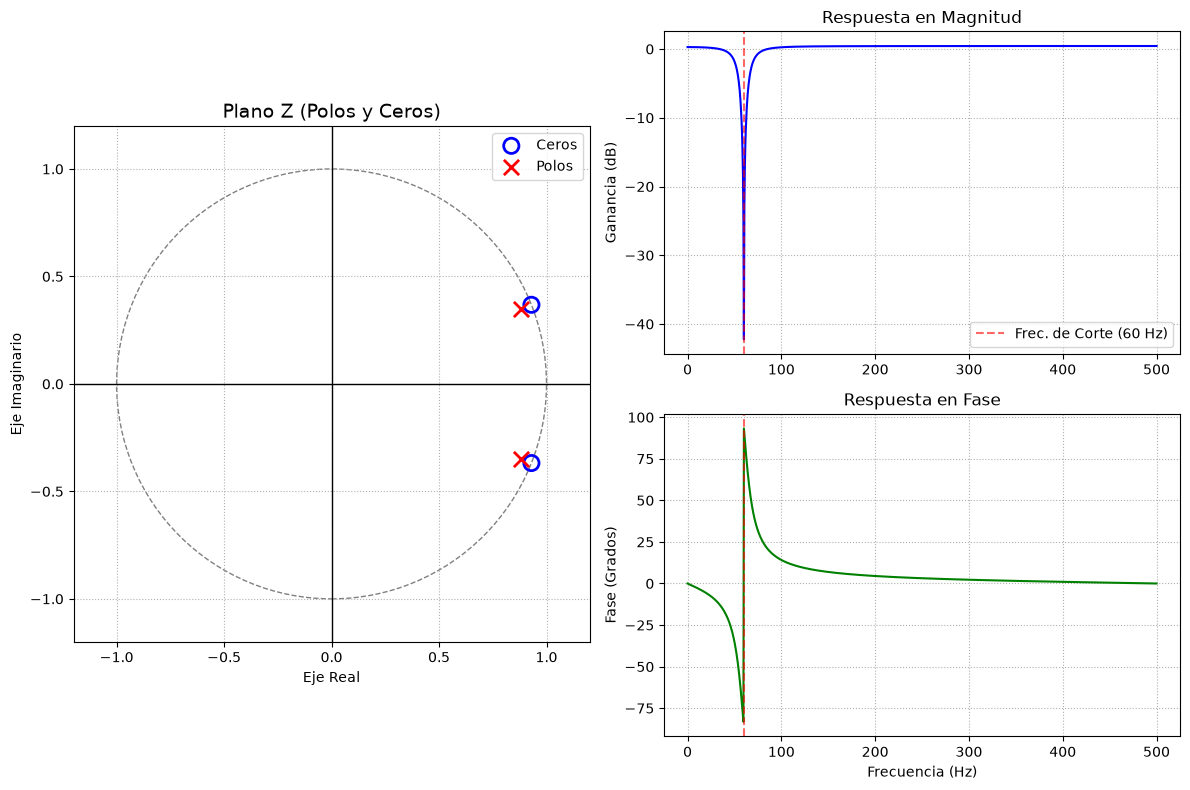

In [12]:
# ==========================================
# 2. EXTRACCIÓN DE POLOS Y CEROS (SYMPY)
# ==========================================
# Resolvemos H(z) = 0 (ceros) y el denominador = 0 (polos)
ceros_sym = sp.solve(numerador, z)
polos_sym = sp.solve(denominador, z)

# Convertimos los resultados simbólicos a tipos complejos nativos de Python
ceros = [complex(c.evalf()) for c in ceros_sym]
polos = [complex(p.evalf()) for p in polos_sym]

# ==========================================
# 3. RESPUESTA EN FRECUENCIA (BODE)
# ==========================================
# Sustituimos z = e^(jw) en H(z) para evaluar la respuesta frecuencial
H_w = H_z.subs(z, sp.exp(sp.I * w))

# lambdify convierte la expresión de SymPy en una función rápida de NumPy
H_func = sp.lambdify(w, H_w, modules="numpy")

# Generamos un vector de frecuencias digitales (de 0 a pi)
w_vals = np.linspace(0, np.pi, 1000)
freq_hz = w_vals * (Fs / (2 * np.pi)) # Conversión a Hz reales

# Evaluamos la función y calculamos magnitud (dB) y fase (grados)
H_vals = H_func(w_vals)
magnitud_db = 20 * np.log10(np.abs(H_vals))
fase_deg = np.angle(H_vals, deg=True)

# ==========================================
# 4. VISUALIZACIÓN MULTIPANEL
# ==========================================
fig = plt.figure(figsize=(12, 8))

# --- Gráfico 1: Plano Complejo (Polos y Ceros) ---
ax1 = plt.subplot(1, 2, 1)
circulo = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax1.add_patch(circulo)
ax1.axhline(0, color='black', lw=1)
ax1.axvline(0, color='black', lw=1)
ax1.scatter([np.real(c) for c in ceros], [np.imag(c) for c in ceros], 
            s=120, facecolors='none', edgecolors='blue', marker='o', lw=2, label='Ceros')
ax1.scatter([np.real(p) for p in polos], [np.imag(p) for p in polos], 
            s=120, color='red', marker='x', lw=2, label='Polos')
ax1.set_xlim([-1.2, 1.2])
ax1.set_ylim([-1.2, 1.2])
ax1.set_aspect('equal')
ax1.set_title("Plano Z (Polos y Ceros)", fontsize=14)
ax1.set_xlabel("Eje Real")
ax1.set_ylabel("Eje Imaginario")
ax1.grid(True, linestyle=':')
ax1.legend()

# --- Gráfico 2: Magnitud (Bode Superior) ---
ax2 = plt.subplot(2, 2, 2)
ax2.plot(freq_hz, magnitud_db, 'b')
ax2.axvline(f0, color='red', linestyle='--', alpha=0.6, label='Frec. de Corte (60 Hz)')
ax2.set_title("Respuesta en Magnitud", fontsize=12)
ax2.set_ylabel("Ganancia (dB)")
ax2.grid(True, linestyle=':')
ax2.legend()

# --- Gráfico 3: Fase (Bode Inferior) ---
ax3 = plt.subplot(2, 2, 4, sharex=ax2)
ax3.plot(freq_hz, fase_deg, 'green')
ax3.axvline(f0, color='red', linestyle='--', alpha=0.6)
ax3.set_title("Respuesta en Fase", fontsize=12)
ax3.set_xlabel("Frecuencia (Hz)")
ax3.set_ylabel("Fase (Grados)")
ax3.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

Coeficientes b (Numerador / Feedforward): [ 0.83979965 -1.56165193  0.83979965]
Coeficientes a (Denominador / Feedback): [ 1.         -1.56165193  0.6795993 ]


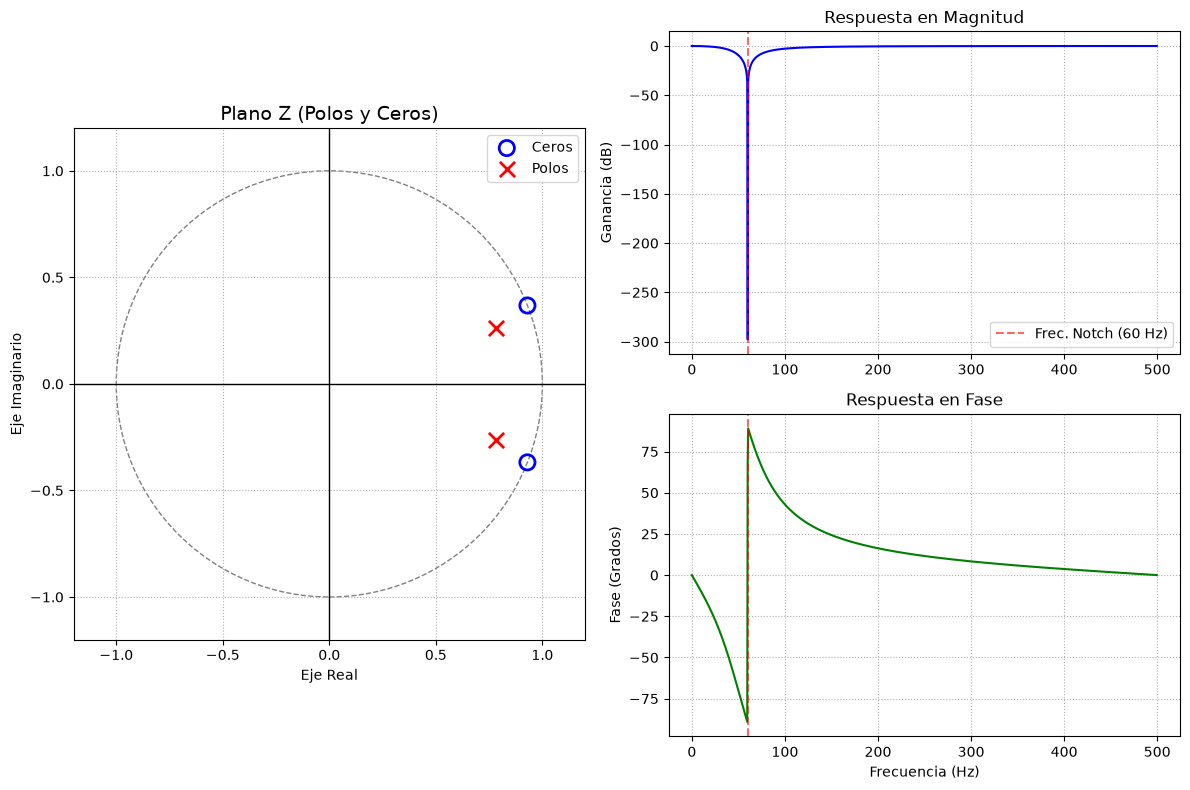

In [22]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# ==========================================
# 1. DISEÑO DEL FILTRO (SCIPY SIGNAL)
# ==========================================
Fs = 1000.0          # Frecuencia de muestreo (Hz)
f0 = 60.0            # Frecuencia a rechazar (Hz)
Q = 1             # Factor de calidad (determina el ancho de banda)

# iirnotch calcula automáticamente los coeficientes b (feedforward) y a (feedback)
# para un filtro bicuadrático (biquad) de 2do orden.
b, a = signal.iirnotch(w0=f0, Q=Q, fs=Fs)

print("Coeficientes b (Numerador / Feedforward):", b)
print("Coeficientes a (Denominador / Feedback):", a)

# ==========================================
# 2. EXTRACCIÓN DE POLOS Y CEROS
# ==========================================
# tf2zpk (Transfer Function to Zero-Pole-Gain) extrae las raíces directamente
ceros, polos, ganancia = signal.tf2zpk(b, a)

# ==========================================
# 3. RESPUESTA EN FRECUENCIA (BODE)
# ==========================================
# freqz evalúa la respuesta frecuencial H(e^jw) del filtro
# worN=1000 indica la cantidad de puntos de resolución
freq_hz, H_vals = signal.freqz(b, a, worN=1000, fs=Fs)

# Conversión a Magnitud (dB) y Fase (grados)
magnitud_db = 20 * np.log10(np.abs(H_vals))
fase_deg = np.angle(H_vals, deg=True)

# ==========================================
# 4. VISUALIZACIÓN MULTIPANEL
# ==========================================
fig = plt.figure(figsize=(12, 8))

# --- Gráfico 1: Plano Complejo (Polos y Ceros) ---
ax1 = plt.subplot(1, 2, 1)
circulo = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax1.add_patch(circulo)
ax1.axhline(0, color='black', lw=1)
ax1.axvline(0, color='black', lw=1)

# Graficamos ceros y polos extrayendo su parte real e imaginaria
ax1.scatter(np.real(ceros), np.imag(ceros), s=120, facecolors='none', 
            edgecolors='blue', marker='o', lw=2, label='Ceros')
ax1.scatter(np.real(polos), np.imag(polos), s=120, color='red', 
            marker='x', lw=2, label='Polos')

ax1.set_xlim([-1.2, 1.2])
ax1.set_ylim([-1.2, 1.2])
ax1.set_aspect('equal')
ax1.set_title("Plano Z (Polos y Ceros)", fontsize=14)
ax1.set_xlabel("Eje Real")
ax1.set_ylabel("Eje Imaginario")
ax1.grid(True, linestyle=':')
ax1.legend()

# --- Gráfico 2: Magnitud (Bode Superior) ---
ax2 = plt.subplot(2, 2, 2)
ax2.plot(freq_hz, magnitud_db, 'b')
ax2.axvline(f0, color='red', linestyle='--', alpha=0.6, label='Frec. Notch (60 Hz)')
ax2.set_title("Respuesta en Magnitud", fontsize=12)
ax2.set_ylabel("Ganancia (dB)")
ax2.grid(True, linestyle=':')
ax2.legend()

# --- Gráfico 3: Fase (Bode Inferior) ---
ax3 = plt.subplot(2, 2, 4, sharex=ax2)
ax3.plot(freq_hz, fase_deg, 'green')
ax3.axvline(f0, color='red', linestyle='--', alpha=0.6)
ax3.set_title("Respuesta en Fase", fontsize=12)
ax3.set_xlabel("Frecuencia (Hz)")
ax3.set_ylabel("Fase (Grados)")
ax3.grid(True, linestyle=':')

plt.tight_layout()
plt.show()